In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.preprocessing import QuantileTransformer
from sklearn.model_selection import train_test_split
from scipy.stats import kstest

In [2]:
df_2018 = pd.read_parquet('../data/raw/2018/2018.parquet')
df_2018.columns = df_2018.columns.str.strip()
df_2018.head()

,Dst Port,Protocol,Timestamp,Flow Duration,Tot Fwd Pkts,Tot Bwd Pkts,TotLen Fwd Pkts,TotLen Bwd Pkts,Fwd Pkt Len Max,Fwd Pkt Len Min,...,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label,Flow ID,Src IP,Src Port,Dst IP
0,0,0,14/02/2018 08:31:01,112641719,3,0,0,0,0,0,...,0,56320859.5,139.3000358938,56320958,56320761,Benign,NaN,NaN,NaN,NaN
1,0,0,14/02/2018 08:33:50,112641466,3,0,0,0,0,0,...,0,56320733.0,114.5512985522,56320814,56320652,Benign,NaN,NaN,NaN,NaN
2,0,0,14/02/2018 08:36:39,112638623,3,0,0,0,0,0,...,0,56319311.5,301.9345955667,56319525,56319098,Benign,NaN,NaN,NaN,NaN
3,22,6,14/02/2018 08:40:13,6453966,15,10,1239,2273,744,0,...,0,0.0,0.0,0,0,Benign,NaN,NaN,NaN,NaN
4,22,6,14/02/2018 08:40:23,8804066,14,11,1143,2209,744,0,...,0,0.0,0.0,0,0,Benign,NaN,NaN,NaN,NaN


In [3]:
df_2018 = df_2018[df_2018["Label"] != "Label"]

In [4]:
print(df_2018.shape)
print(df_2018.dtypes.value_counts())

(16232943, 84)
str        83
float64     1
Name: count, dtype: int64


In [5]:
df_2018.isna().sum()

Dst Port               0
Protocol               0
Timestamp              0
Flow Duration          0
Tot Fwd Pkts           0
                  ...   
Label                  0
Flow ID          8284195
Src IP           8284195
Src Port         8284195
Dst IP           8284195
Length: 84, dtype: int64

In [6]:
df_2018.drop(columns=["Flow ID", "Src IP", "Src Port", "Dst IP", "Timestamp", "Protocol"], inplace=True)

In [7]:
cols = [c for c in df_2018.columns if c != "Label"]

for col in cols:
    df_2018[col] = pd.to_numeric(df_2018[col], errors='coerce').astype('float32')

df_2018[cols] = df_2018[cols].replace([np.inf, -np.inf], np.nan)

nan_after = df_2018.isna().sum()
print(nan_after[nan_after > 0])
print(f"\nTotal lignes : {len(df_2018)}")

Flow Byts/s    95760
Flow Pkts/s    95760
dtype: int64

Total lignes : 16232943


In [8]:
df_2018.dropna(inplace=True)
print(f"Total lignes après  : {len(df_2018)}")

Total lignes après  : 16137183


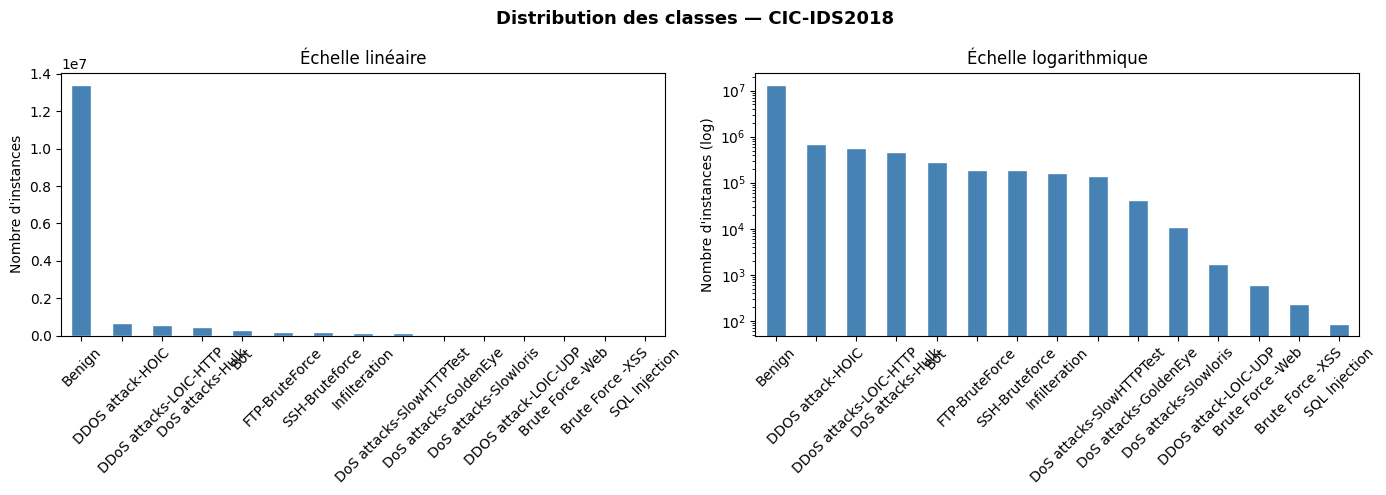

In [9]:
label_counts = df_2018["Label"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Distribution des classes — CIC-IDS2018", fontsize=13, fontweight="bold")

label_counts.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Échelle linéaire")
axes[0].set_xlabel("")
axes[0].set_ylabel("Nombre d'instances")
axes[0].tick_params(axis="x", rotation=45)

label_counts.plot(kind="bar", ax=axes[1], color="steelblue", edgecolor="white", logy=True)
axes[1].set_title("Échelle logarithmique")
axes[1].set_xlabel("")
axes[1].set_ylabel("Nombre d'instances (log)")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

In [10]:
df_2018['Label'].unique()

<ArrowStringArray>
[                  'Benign',           'FTP-BruteForce',
           'SSH-Bruteforce',    'DoS attacks-GoldenEye',
    'DoS attacks-Slowloris', 'DoS attacks-SlowHTTPTest',
         'DoS attacks-Hulk',   'DDoS attacks-LOIC-HTTP',
     'DDOS attack-LOIC-UDP',         'DDOS attack-HOIC',
         'Brute Force -Web',         'Brute Force -XSS',
            'SQL Injection',            'Infilteration',
                      'Bot']
Length: 15, dtype: str

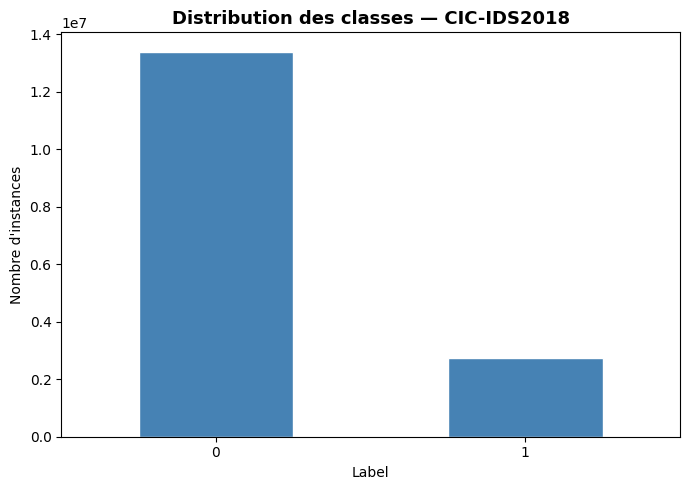

In [11]:
df_2018["Label"] = df_2018["Label"].map(lambda x: 0 if x == "Benign" or x == 0 else 1)

label_counts = df_2018["Label"].value_counts()

plt.figure(figsize=(7, 5))

label_counts.plot(
    kind="bar",
    color="steelblue",
    edgecolor="white"
)

plt.title("Distribution des classes — CIC-IDS2018", fontsize=13, fontweight="bold")
plt.ylabel("Nombre d'instances")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [12]:
df_2018.columns

Index(['Dst Port', 'Flow Duration', 'Tot Fwd Pkts', 'Tot Bwd Pkts',
       'TotLen Fwd Pkts', 'TotLen Bwd Pkts', 'Fwd Pkt Len Max',
       'Fwd Pkt Len Min', 'Fwd Pkt Len Mean', 'Fwd Pkt Len Std',
       'Bwd Pkt Len Max', 'Bwd Pkt Len Min', 'Bwd Pkt Len Mean',
       'Bwd Pkt Len Std', 'Flow Byts/s', 'Flow Pkts/s', 'Flow IAT Mean',
       'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Tot',
       'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min',
       'Bwd IAT Tot', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags',
       'Bwd URG Flags', 'Fwd Header Len', 'Bwd Header Len', 'Fwd Pkts/s',
       'Bwd Pkts/s', 'Pkt Len Min', 'Pkt Len Max', 'Pkt Len Mean',
       'Pkt Len Std', 'Pkt Len Var', 'FIN Flag Cnt', 'SYN Flag Cnt',
       'RST Flag Cnt', 'PSH Flag Cnt', 'ACK Flag Cnt', 'URG Flag Cnt',
       'CWE Flag Count', 'ECE Flag Cnt', 'Down/Up Ratio', 'Pkt Size Avg',
       'Fwd Seg Size Avg', 'Bwd

In [13]:
rename_map = {
    "Dst Port"          : "Destination Port",
    "Tot Fwd Pkts"      : "Total Fwd Packets",
    "Tot Bwd Pkts"      : "Total Backward Packets",
    "TotLen Fwd Pkts"   : "Total Length of Fwd Packets",
    "TotLen Bwd Pkts"   : "Total Length of Bwd Packets",
    "Fwd Pkt Len Max"   : "Fwd Packet Length Max",
    "Fwd Pkt Len Min"   : "Fwd Packet Length Min",
    "Fwd Pkt Len Mean"  : "Fwd Packet Length Mean",
    "Fwd Pkt Len Std"   : "Fwd Packet Length Std",
    "Bwd Pkt Len Max"   : "Bwd Packet Length Max",
    "Bwd Pkt Len Min"   : "Bwd Packet Length Min",
    "Bwd Pkt Len Mean"  : "Bwd Packet Length Mean",
    "Bwd Pkt Len Std"   : "Bwd Packet Length Std",
    "Flow Byts/s"       : "Flow Bytes/s",
    "Flow Pkts/s"       : "Flow Packets/s",
    "Fwd IAT Tot"       : "Fwd IAT Total",
    "Bwd IAT Tot"       : "Bwd IAT Total",
    "Fwd Header Len"    : "Fwd Header Length",
    "Bwd Header Len"    : "Bwd Header Length",
    "Fwd Pkts/s"        : "Fwd Packets/s",
    "Bwd Pkts/s"        : "Bwd Packets/s",
    "Pkt Len Min"       : "Min Packet Length",
    "Pkt Len Max"       : "Max Packet Length",
    "Pkt Len Mean"      : "Packet Length Mean",
    "Pkt Len Std"       : "Packet Length Std",
    "Pkt Len Var"       : "Packet Length Variance",
    "FIN Flag Cnt"      : "FIN Flag Count",
    "SYN Flag Cnt"      : "SYN Flag Count",
    "RST Flag Cnt"      : "RST Flag Count",
    "PSH Flag Cnt"      : "PSH Flag Count",
    "ACK Flag Cnt"      : "ACK Flag Count",
    "URG Flag Cnt"      : "URG Flag Count",
    "ECE Flag Cnt"      : "ECE Flag Count",
    "Pkt Size Avg"      : "Average Packet Size",
    "Fwd Seg Size Avg"  : "Avg Fwd Segment Size",
    "Bwd Seg Size Avg"  : "Avg Bwd Segment Size",
    "Fwd Byts/b Avg"    : "Fwd Avg Bytes/Bulk",
    "Fwd Pkts/b Avg"    : "Fwd Avg Packets/Bulk",
    "Fwd Blk Rate Avg"  : "Fwd Avg Bulk Rate",
    "Bwd Byts/b Avg"    : "Bwd Avg Bytes/Bulk",
    "Bwd Pkts/b Avg"    : "Bwd Avg Packets/Bulk",
    "Bwd Blk Rate Avg"  : "Bwd Avg Bulk Rate",
    "Subflow Fwd Pkts"  : "Subflow Fwd Packets",
    "Subflow Fwd Byts"  : "Subflow Fwd Bytes",
    "Subflow Bwd Pkts"  : "Subflow Bwd Packets",
    "Subflow Bwd Byts"  : "Subflow Bwd Bytes",
    "Init Fwd Win Byts" : "Init_Win_bytes_forward",
    "Init Bwd Win Byts" : "Init_Win_bytes_backward",
    "Fwd Act Data Pkts" : "act_data_pkt_fwd",
    "Fwd Seg Size Min"  : "min_seg_size_forward",
}



In [14]:
df_2018.rename(columns=rename_map, inplace=True)

In [15]:
df_train_2017 = pd.read_csv('../data/processed/2017/2017_train_scaled.csv')
df_test_2017 = pd.read_csv('../data/processed/2017/2017_test_scaled.csv')
df_2017 = pd.concat([df_train_2017,df_test_2017], ignore_index=True)
print(df_2017.shape)
print(df_2017.columns.tolist())

(2827876, 50)
['Destination Port', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Std', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length', 'Bwd Packets/s', 'Min Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio', 'Avg Fwd Segment Size', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd', 'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Std', 'Idle Max', 'Label']


In [16]:
len(df_2017.columns)

50

In [17]:
final_cols = df_2017.columns.tolist()


missing = [c for c in final_cols if c not in df_2018.columns]
print(f"Colonnes manquantes : {missing}")


df_2018_final = df_2018[final_cols]

Colonnes manquantes : []


In [18]:
len(df_2018_final.columns)

50

In [19]:
df_2018_final.columns

Index(['Destination Port', 'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Std', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Min',
       'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Min',
       'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max',
       'Bwd IAT Min', 'Fwd Header Length', 'Bwd Header Length',
       'Bwd Packets/s', 'Min Packet Length', 'Packet Length Mean',
       'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count',
       'SYN Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',
       'CWE Flag Count', 'ECE Flag Count', 'Down/Up Ratio',
       'Avg Fwd Segment Size', 'Subflow Fwd Bytes', 'Subflow Bwd Packets',
       'Init_Win_bytes_forward', 'Init_Win_bytes_backward', 'act_data_pkt_fwd',
       'min_seg_size_forward', 'Active Mean', 'Active Std', 'Active Max',
       

In [20]:
stats = []

for col in df_2018_final.columns:
    stat, p_value = kstest(df_2018_final[col],df_2017[col])
    print(f"Stats : {stat}, p-value : {p_value}, column : {col}")
    stats.append(stat)

Stats : 0.9852054723553672, p-value : 0.0, column : Destination Port
Stats : 0.7790147092729667, p-value : 0.0, column : Fwd Packet Length Max
Stats : 0.6424019299290351, p-value : 0.0, column : Fwd Packet Length Min
Stats : 0.7683529970903957, p-value : 0.0, column : Fwd Packet Length Std
Stats : 0.6468579244634489, p-value : 0.0, column : Bwd Packet Length Min
Stats : 0.8062708548748247, p-value : 0.0, column : Bwd Packet Length Mean
Stats : 0.7842338207191546, p-value : 0.0, column : Bwd Packet Length Std
Stats : 0.9116255451087671, p-value : 0.0, column : Flow Bytes/s
Stats : 0.9060482438753757, p-value : 0.0, column : Flow Packets/s
Stats : 0.9675678747447223, p-value : 0.0, column : Flow IAT Mean
Stats : 0.8214302890225739, p-value : 0.0, column : Flow IAT Std
Stats : 0.9805477225322717, p-value : 0.0, column : Flow IAT Min
Stats : 0.8391246810834089, p-value : 0.0, column : Fwd IAT Total
Stats : 0.8354512526869728, p-value : 0.0, column : Fwd IAT Mean
Stats : 0.8341995900810361,

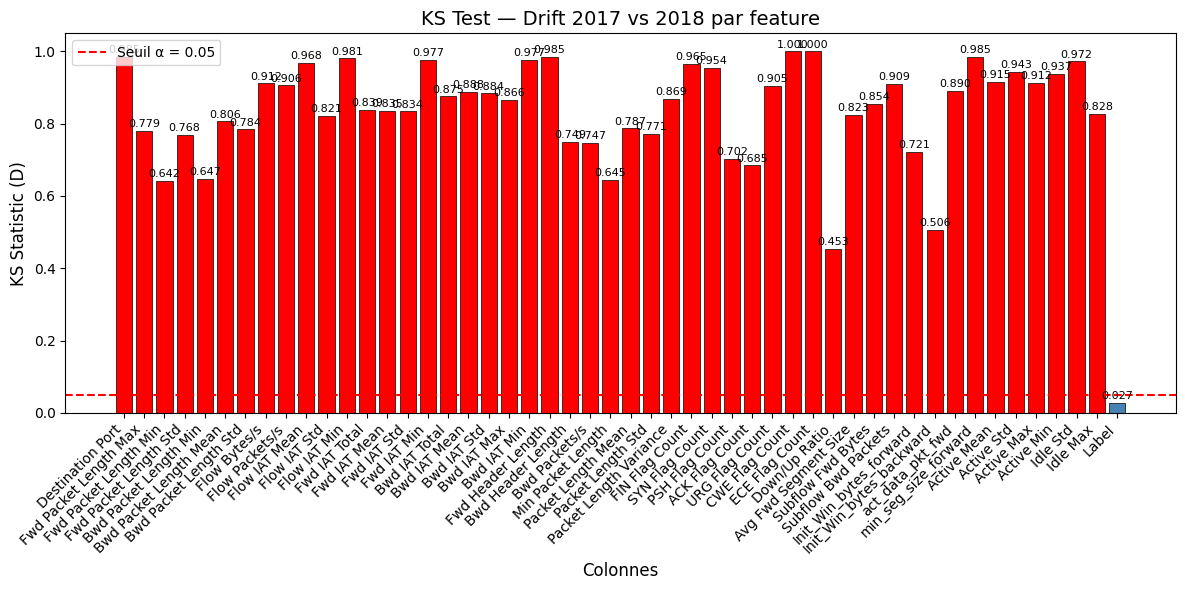

In [21]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = ['red' if s > 0.05 else 'steelblue' for s in stats]
bars = ax.bar(df_2018_final.columns, stats, color=colors, edgecolor='black', linewidth=0.5)

for bar, val in zip(bars, stats):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.axhline(y=0.05, color='red', linestyle='--', linewidth=1.5, label='Seuil α = 0.05')
ax.set_xlabel('Colonnes', fontsize=12)
ax.set_ylabel('KS Statistic (D)', fontsize=12)
ax.set_title('KS Test — Drift 2017 vs 2018 par feature', fontsize=14)
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [22]:
X = df_2018_final.drop(columns=["Label"])
y = df_2018_final["Label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train : {X_train.shape} | Test : {X_test.shape}")

Train : (12909746, 49) | Test : (3227437, 49)


In [24]:
qt = QuantileTransformer(output_distribution='normal',n_quantiles=50000,subsample=1000000,random_state=42)
X_scaled_train = pd.DataFrame(qt.fit_transform(X_train), columns=X.columns)
X_scaled_test = pd.DataFrame(qt.transform(X_test), columns=X.columns)

In [25]:
X_scaled_train["Label"] = y_train.values
X_scaled_test["Label"] = y_test.values

X_scaled_train.to_parquet("../data/processed/2018/2018_train_scaled.parquet", index=False)
X_scaled_test.to_parquet("../data/processed/2018/2018_test_scaled.parquet", index=False)

print(f"Train sauvegardé : {X_scaled_train.shape}")
print(f"Test sauvegardé  : {X_scaled_test.shape}")

Train sauvegardé : (12909746, 50)
Test sauvegardé  : (3227437, 50)
